The aim of this is to some form of marketing analysis. To see if there are states with a high survey completion rate. Or more importantly, to determine those states with a very low response rate. This insight could then be used to change tactics when surveying different states

In [1]:
import numpy as np
import pandas as pd
import polars as pl 
import seaborn as sns
import matplotlib.pyplot as plt
import pyarrow as pa
import sys



# Import state call data

State_Codes = pl.read_csv('../Ref_Data/State_Code.csv')
Surveys = pl.read_csv('../CleanedData/2011.csv')


In [2]:
Survey_By_State = Surveys['_STATE', 'DISPCODE']
Survey_By_State_Cast = Survey_By_State.with_columns(
    pl.col('_STATE').cast(pl.Int64)
)

Survey_Completion_By_State = Survey_By_State_Cast.join(State_Codes, on='_STATE', how='left')

Survey_State_Name = Survey_Completion_By_State.select(['State', 'DISPCODE'])

Total_Surveys_By_State = Survey_State_Name.group_by('State').count()

Survey_W_Responses = Survey_State_Name.with_columns(
    pl.col('DISPCODE').cast(pl.String)
)

Survey_W_Responses=Survey_W_Responses.with_columns(
    pl.col('DISPCODE').replace('120.0', 'Incomplete').replace('110.0', 'Complete')).rename({'DISPCODE':'Completeness'}).sort('State')




print(Survey_W_Responses)


shape: (506_467, 2)
┌─────────┬──────────────┐
│ State   ┆ Completeness │
│ ---     ┆ ---          │
│ str     ┆ str          │
╞═════════╪══════════════╡
│ Alabama ┆ Incomplete   │
│ Alabama ┆ Incomplete   │
│ Alabama ┆ Incomplete   │
│ Alabama ┆ Incomplete   │
│ Alabama ┆ Incomplete   │
│ …       ┆ …            │
│ Wyoming ┆ Incomplete   │
│ Wyoming ┆ Complete     │
│ Wyoming ┆ Complete     │
│ Wyoming ┆ Complete     │
│ Wyoming ┆ Complete     │
└─────────┴──────────────┘


<ipython-input-2-b9bf29023e84>:10: DeprecationWarning: `GroupBy.count` is deprecated. It has been renamed to `len`.
  Total_Surveys_By_State = Survey_State_Name.group_by('State').count()


Plotting Survey completness against State to investigate whether residents of different states were more likely to answer.
First we will look at the total number of calls per state to see if the higher population states reply more simply due to higher survey volume. 
Then we will look at the responses per to survey to each state to determine whether certain states were proportionatly more likely to respond.
As there are so many stats, it will make interpretting graphs difficult so we will be breaking it up by region, Northeast, Southeast, NorthWest and SouthWest

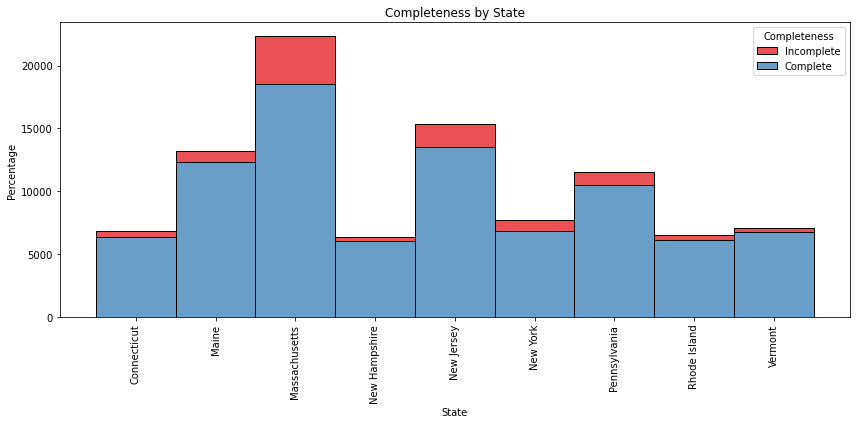

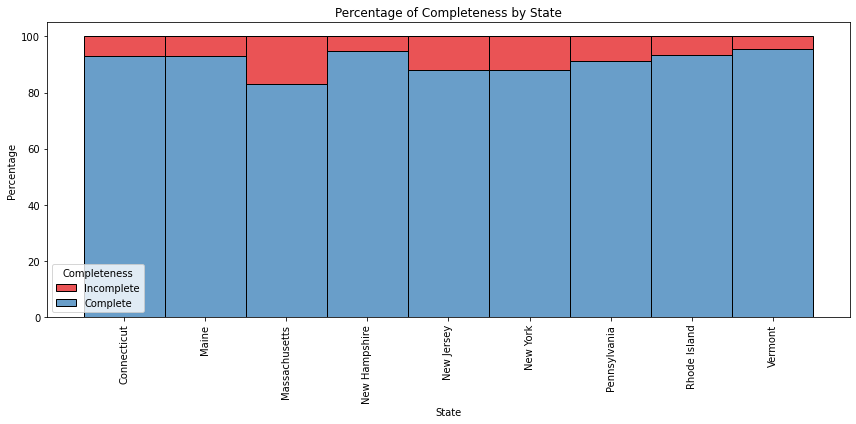

In [45]:
# Notheast States


Survey_W_Responses_NE = Survey_W_Responses.filter(
    pl.col('State').is_in([
        'New York', 'Connecticut', 'Maine', 'Massachusetts', 
        'New Hampshire', 'Rhode Island', 'Vermont', 
        'New Jersey', 'Pennsylvania'
    ])
)


Survey_W_Responses_NE_Per = Survey_W_Responses_NE.group_by(['State', 'Completeness']).agg(
    pl.len().alias('count')
).with_columns(
    (pl.col('count') / pl.col('count').sum().over('State') * 100).round(2).alias('percentage')
).sort(['State', 'Completeness'])



plt.figure(figsize=(12, 6))
sns.histplot(data=Survey_W_Responses_NE_Per, 
        x='State', 
        weights='count', 
        hue='Completeness', 
        multiple='stack',
        hue_order=['Incomplete', 'Complete'],
        palette='Set1')
plt.xticks(rotation=90)
plt.xlabel('State')
plt.ylabel('Percentage')
plt.title('Completeness by State')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.histplot(data=Survey_W_Responses_NE_Per, 
        x='State', 
        weights='percentage', 
        hue='Completeness', 
        multiple='stack', 
        hue_order=['Incomplete', 'Complete'],
        palette='Set1'
        )
plt.xticks(rotation=90)
plt.xlabel('State')
plt.ylabel('Percentage')
plt.title('Percentage of Completeness by State')
plt.tight_layout()
plt.show()


In [ ]:
# Northwest States

Survey_W_Responses_NW = Survey_W_Responses.filter(
    pl.col('State').is_in([
        'Washington', 'Oregon', 'Idaho', 'Montana', 'Wyoming', 'Alaska'
    ])
)

Survey_W_Responses_NW_Per = Survey_W_Responses_NW.group_by(['State', 'Completeness']).agg(
    pl.len().alias('count')
).with_columns(
    (pl.col('count') / pl.col('count').sum().over('State') * 100).round(2).alias('percentage')
).sort(['State', 'Completeness'])

plt.figure(figsize=(8, 6))
sns.histplot(data=Survey_W_Responses_NW_Per, 
        x='State', 
        weights='count', 
        hue='Completeness', 
        multiple='stack',
        hue_order=['Incomplete', 'Complete'],
        palette='Set1')
plt.xticks(rotation=90)
plt.xlabel('State')
plt.ylabel('Percentage')
plt.title('Completeness by State')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.histplot(data=Survey_W_Responses_NW_Per, 
        x='State', 
        weights='percentage', 
        hue='Completeness', 
        multiple='stack', 
        hue_order=['Incomplete', 'Complete'],
        palette='Set1'
        )
plt.xticks(rotation=90)
plt.xlabel('State')
plt.ylabel('Percentage')
plt.title('Percentage of Completeness by State')
plt.tight_layout()
plt.show()

In [ ]:
Survey_W_Responses_SW = Survey_W_Responses.filter(
    pl.col('State').is_in([
        'Arizona', 'New Mexico', 'Nevada', 'Utah', 'Colorado',
        'California', 'Texas', 'Hawaii'
    ])
)

Survey_W_Responses_SW_Per = Survey_W_Responses_SW.group_by(['State', 'Completeness']).agg(
    pl.len().alias('count')
).with_columns(
    (pl.col('count') / pl.col('count').sum().over('State') * 100).round(2).alias('percentage')
).sort(['State', 'Completeness'])

plt.figure(figsize=(8, 6))
sns.histplot(data=Survey_W_Responses_SW_Per, 
        x='State', 
        weights='count', 
        hue='Completeness', 
        multiple='stack',
        hue_order=['Incomplete', 'Complete'],
        palette='Set1')
plt.xticks(rotation=90)
plt.xlabel('State')
plt.ylabel('Percentage')
plt.title('Completeness by State')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.histplot(data=Survey_W_Responses_SW_Per, 
        x='State', 
        weights='percentage', 
        hue='Completeness', 
        multiple='stack', 
        hue_order=['Incomplete', 'Complete'],
        palette='Set1'
        )
plt.xticks(rotation=90)
plt.xlabel('State')
plt.ylabel('Percentage')
plt.title('Percentage of Completeness by State')
plt.tight_layout()
plt.show()

In [ ]:
Survey_W_Responses_SE = Survey_W_Responses.filter(
    pl.col('State').is_in([
        'Florida', 'Georgia', 'Alabama', 'Mississippi', 'South Carolina',
        'North Carolina', 'Tennessee', 'Arkansas', 'Louisiana', 'Virginia',
        'West Virginia', 'Kentucky'
    ])
)

Survey_W_Responses_SE_Per = Survey_W_Responses_SE.group_by(['State', 'Completeness']).agg(
    pl.len().alias('count')
).with_columns(
    (pl.col('count') / pl.col('count').sum().over('State') * 100).round(2).alias('percentage')
).sort(['State', 'Completeness'])

plt.figure(figsize=(8, 6))
sns.histplot(data=Survey_W_Responses_SE_Per, 
        x='State', 
        weights='count', 
        hue='Completeness', 
        multiple='stack',
        hue_order=['Incomplete', 'Complete'],
        palette='Set1')
plt.xticks(rotation=90)
plt.xlabel('State')
plt.ylabel('Percentage')
plt.title('Completeness by State')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.histplot(data=Survey_W_Responses_SE_Per, 
        x='State', 
        weights='percentage', 
        hue='Completeness', 
        multiple='stack', 
        hue_order=['Incomplete', 'Complete'],
        palette='Set1'
        )
plt.xticks(rotation=90)
plt.xlabel('State')
plt.ylabel('Percentage')
plt.title('Percentage of Completeness by State')
plt.tight_layout()
plt.show()

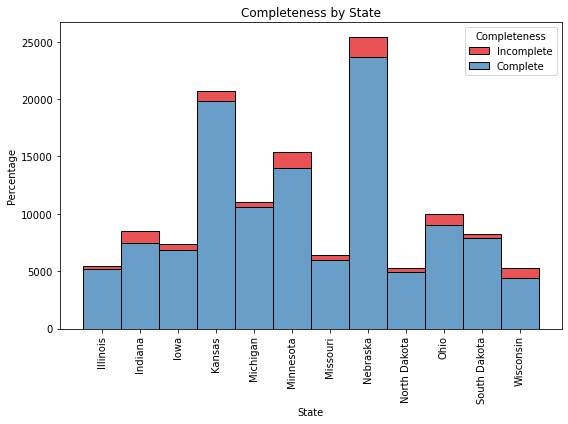

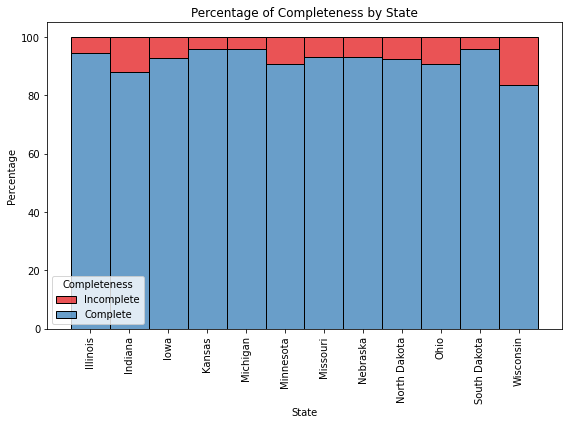

In [53]:
Survey_W_Responses_MW = Survey_W_Responses.filter(
    pl.col('State').is_in([
        'North Dakota', 'South Dakota', 'Nebraska', 'Kansas',
        'Minnesota', 'Iowa', 'Missouri', 'Wisconsin', 'Michigan',
        'Illinois','Indiana', 'Ohio'
    ])
)

Survey_W_Responses_MW_Per = Survey_W_Responses_MW.group_by(['State', 'Completeness']).agg(
    pl.len().alias('count')
).with_columns(
    (pl.col('count') / pl.col('count').sum().over('State') * 100).round(2).alias('percentage')
).sort(['State', 'Completeness'])

plt.figure(figsize=(8, 6))
sns.histplot(data=Survey_W_Responses_MW_Per, 
        x='State', 
        weights='count', 
        hue='Completeness', 
        multiple='stack',
        hue_order=['Incomplete', 'Complete'],
        palette='Set1')
plt.xticks(rotation=90)
plt.xlabel('State')
plt.ylabel('Percentage')
plt.title('Completeness by State')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.histplot(data=Survey_W_Responses_MW_Per, 
        x='State', 
        weights='percentage', 
        hue='Completeness', 
        multiple='stack', 
        hue_order=['Incomplete', 'Complete'],
        palette='Set1'
        )
plt.xticks(rotation=90)
plt.xlabel('State')
plt.ylabel('Percentage')
plt.title('Percentage of Completeness by State')
plt.tight_layout()
plt.show()